   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 40.2 MB/s eta 0:00:00
Starting pIC50 Prediction for Poly-Pyridine Ligands

Example Dataset:
----------------------------------------
                                 SMILES  pIC50
0        c1ccnc(c1)c2ccnc(n2)c3ccnc(n3)    7.2
1    c1cc(nc(c1)C)c2ccnc(n2)c3ccnc(n3)C    6.8
2  c1cc(nc(c1)Cl)c2ccnc(n2)c3ccnc(n3)Cl    7.5
3                  c1ccnc(c1)c2ccnc(n2)    6.2
4              c1cc(nc(c1)C)c2ccnc(n2)C    5.8
Processing molecular features...
Processed 10 valid molecules out of 13
Feature matrix shape: (10, 2054)
Training models...


[20:25:35] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
[20:25:35] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
[20:25:35] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10



MODEL PERFORMANCE RESULTS

Random Forest:
  R² Score: 0.2788
  RMSE: 0.2123
  MSE: 0.0451

XGBoost:
  R² Score: 0.7097
  RMSE: 0.1347
  MSE: 0.0181


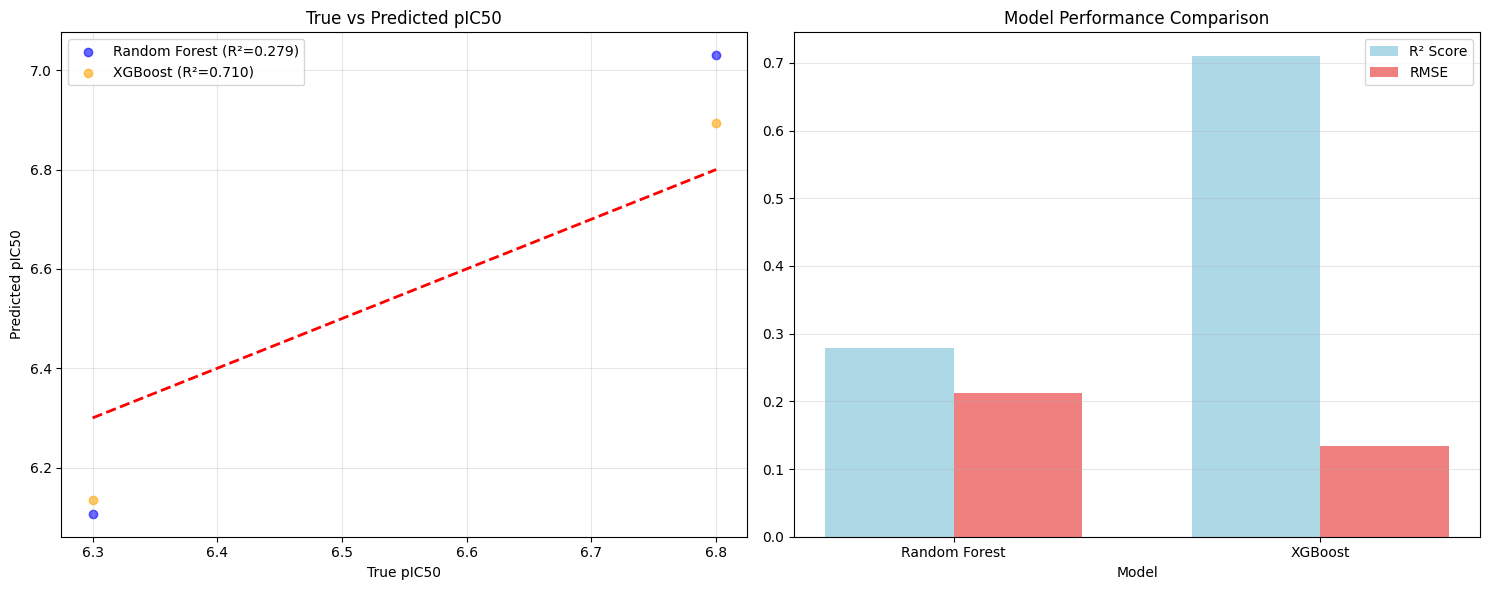


PREDICTING NEW COMPOUNDS

Predictions for new compounds:
----------------------------------------
                       SMILES  Predicted_pIC50
0    c1cc(nc(c1)I)c2ccnc(n2)I         6.130483
1  c1cc(nc(c1)CN)c2ccnc(n2)CN         6.893764


[20:25:47] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10


In [ ]:
!pip install rdkit

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdFingerprintGenerator
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

def preprocess_data(smiles_list, pic50_values):
    """
    Process SMILES strings and extract molecular features
    """
    features = []
    valid_indices = []
    valid_smiles = []

    for i, smile in enumerate(smiles_list):
        try:
            mol = Chem.MolFromSmiles(smile)
            if mol:
                # Molecular descriptors
                mol_wt = Descriptors.MolWt(mol)
                logp = Descriptors.MolLogP(mol)
                hbd = Descriptors.NumHDonors(mol)
                hba = Descriptors.NumHAcceptors(mol)
                tpsa = Descriptors.TPSA(mol)
                rotatable_bonds = Descriptors.NumRotatableBonds(mol)

                # Morgan fingerprints (ECFP4)
                fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
                fingerprint = np.array(fp_gen.GetFingerprintAsNumPy(mol))

                # Combine features
                basic_features = [mol_wt, logp, hbd, hba, tpsa, rotatable_bonds]
                all_features = np.concatenate([basic_features, fingerprint])

                features.append(all_features)
                valid_indices.append(i)
                valid_smiles.append(smile)

        except:
            continue

    # Filter corresponding pIC50 values
    filtered_pic50 = [pic50_values[i] for i in valid_indices]

    return np.array(features), np.array(filtered_pic50), valid_smiles

def train_models(X, y, test_size=0.2, random_state=42):
    """
    Train Random Forest and XGBoost models
    """
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Random Forest with hyperparameter tuning
    rf_param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10],
        'min_samples_split': [2, 5]
    }

    rf = RandomForestRegressor(random_state=random_state, n_jobs=-1)
    rf_grid = GridSearchCV(rf, rf_param_grid, cv=3, scoring='neg_mean_squared_error')
    rf_grid.fit(X_train, y_train)
    best_rf = rf_grid.best_estimator_

    # XGBoost with hyperparameter tuning
    xgb_param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.01, 0.1]
    }

    xgb = XGBRegressor(random_state=random_state, n_jobs=-1)
    xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=3, scoring='neg_mean_squared_error')
    xgb_grid.fit(X_train, y_train)
    best_xgb = xgb_grid.best_estimator_

    # Evaluate models
    models = {
        'Random Forest': best_rf,
        'XGBoost': best_xgb
    }

    results = {}
    for name, model in models.items():
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        results[name] = {
            'model': model,
            'mse': mse,
            'rmse': rmse,
            'r2': r2,
            'predictions': y_pred,
            'y_test': y_test
        }

    return results, X_test, y_test

def plot_results(results):
    """
    Plot model performance and predictions
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Scatter plots
    colors = ['blue', 'orange']
    for i, (name, result) in enumerate(results.items()):
        axes[0].scatter(result['y_test'], result['predictions'], alpha=0.6,
                       color=colors[i], label=f'{name} (R²={result["r2"]:.3f})')

    axes[0].plot([min(result['y_test']), max(result['y_test'])],
                 [min(result['y_test']), max(result['y_test'])], 'r--', linewidth=2)
    axes[0].set_xlabel('True pIC50')
    axes[0].set_ylabel('Predicted pIC50')
    axes[0].legend()
    axes[0].set_title('True vs Predicted pIC50')
    axes[0].grid(True, alpha=0.3)

    # Performance comparison
    model_names = list(results.keys())
    r2_scores = [results[name]['r2'] for name in model_names]
    rmse_scores = [results[name]['rmse'] for name in model_names]

    x = np.arange(len(model_names))
    width = 0.35

    axes[1].bar(x - width/2, r2_scores, width, label='R² Score', color='lightblue')
    axes[1].bar(x + width/2, rmse_scores, width, label='RMSE', color='lightcoral')
    axes[1].set_xlabel('Model')
    axes[1].set_title('Model Performance Comparison')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(model_names)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

def predict_pic50(smiles_data, pic50_data):
    """
    Complete workflow for pIC50 prediction
    """
    print("Processing molecular features...")
    X, y, valid_smiles = preprocess_data(smiles_data, pic50_data)

    print(f"Processed {len(valid_smiles)} valid molecules out of {len(smiles_data)}")
    print(f"Feature matrix shape: {X.shape}")

    print("Training models...")
    results, X_test, y_test = train_models(X, y)

    # Print results
    print("\n" + "="*50)
    print("MODEL PERFORMANCE RESULTS")
    print("="*50)
    for name, result in results.items():
        print(f"\n{name}:")
        print(f"  R² Score: {result['r2']:.4f}")
        print(f"  RMSE: {result['rmse']:.4f}")
        print(f"  MSE: {result['mse']:.4f}")

    # Plot results
    plot_results(results)

    return results, valid_smiles

def predict_new_compounds(new_smiles_list, trained_model):
    """
    Predict pIC50 for new poly-pyridine compounds
    """
    # Create dummy pIC50 values for preprocessing
    dummy_pic50 = [0] * len(new_smiles_list)

    # Preprocess new compounds
    X_new, _, valid_smiles = preprocess_data(new_smiles_list, dummy_pic50)

    # Make predictions
    predictions = trained_model.predict(X_new)

    # Create results DataFrame
    results_df = pd.DataFrame({
        'SMILES': valid_smiles,
        'Predicted_pIC50': predictions
    })

    return results_df

# Example poly-pyridine SMILES and pIC50 values
def create_example_data():
    """
    Create example dataset of poly-pyridine ligands with pIC50 values
    """
    example_smiles = [
        # Terpyridine derivatives
        "c1ccnc(c1)c2ccnc(n2)c3ccnc(n3)",  # 2,2':6',2''-terpyridine
        "c1cc(nc(c1)C)c2ccnc(n2)c3ccnc(n3)C",  # Methyl-substituted terpyridine
        "c1cc(nc(c1)Cl)c2ccnc(n2)c3ccnc(n3)Cl",  # Chloro-substituted

        # Bipyridine derivatives
        "c1ccnc(c1)c2ccnc(n2)",  # 2,2'-bipyridine
        "c1cc(nc(c1)C)c2ccnc(n2)C",  # Dimethyl bipyridine
        "c1cc(nc(c1)O)c2ccnc(n2)O",  # Dihydroxy bipyridine

        # Phenanthroline derivatives
        "c1ccc2nccc3ccccc3c2c1",  # 1,10-phenanthroline
        "c1ccc2nccc3c(ccccc13)c2",  # Substituted phenanthroline

        # Extended poly-pyridines
        "c1ccnc(c1)c2cnc(n2)c3ccnc(n3)",  # Extended terpyridine
        "c1cnc(nc1)c2ccnc(n2)c3ccnc(n3)",  # Alternative substitution

        # More examples
        "c1cc(nc(c1)N)c2ccnc(n2)N",  # Diamino bipyridine
        "c1cc(nc(c1)F)c2ccnc(n2)F",  # Difluoro bipyridine
        "c1cc(nc(c1)Br)c2ccnc(n2)Br",  # Dibromo bipyridine
    ]

    # Simulated pIC50 values (ranging from 5.0 to 8.5)
    example_pic50 = [
        7.2, 6.8, 7.5,  # terpyridines
        6.2, 5.8, 6.5,   # bipyridines
        7.8, 7.3,        # phenanthrolines
        6.9, 7.1,        # extended
        5.5, 6.3, 6.0    # substituted
    ]

    return example_smiles, example_pic50

def main():
    """
    Main function to run the complete workflow
    """
    print("Starting pIC50 Prediction for Poly-Pyridine Ligands")
    print("="*60)

    # Create example data
    smiles_data, pic50_data = create_example_data()

    # Display example data
    print("\nExample Dataset:")
    print("-" * 40)
    df_example = pd.DataFrame({
        'SMILES': smiles_data,
        'pIC50': pic50_data
    })
    print(df_example.head())

    # Run prediction pipeline
    results, valid_smiles = predict_pic50(smiles_data, pic50_data)

    # Example: Predict new compounds
    print("\n" + "="*50)
    print("PREDICTING NEW COMPOUNDS")
    print("="*50)

    new_compounds = [
        "c1cc(nc(c1)I)c2ccnc(n2)I",  # New diiodo bipyridine
        "c1cc(nc(c1)CN)c2ccnc(n2)CN",  # New cyano bipyridine
        "c1ccnc(c1)c2cnc(n2)c3cnc(n3)",  # New extended poly-pyridine
    ]

    # Use the best model (XGBoost usually performs better)
    best_model = results['XGBoost']['model']
    new_predictions = predict_new_compounds(new_compounds, best_model)

    print("\nPredictions for new compounds:")
    print("-" * 40)
    print(new_predictions)

    return results

# Run the script
if __name__ == "__main__":
    results = main()